In [7]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
path = "../gdelt_gold_news_sentiment_clean.csv"
df = pd.read_csv(path)
df.head()

,GLD,^GSPC_lag_1,GLD_lag_1,USO_lag_1,SLV_lag_1,EURUSD=X_lag_1,Date_lag_1,sentiment_encoded_lag_1
0,102.199997,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,2.0
1,101.419998,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,2.0
2,101.459999,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,2.0
3,102.889999,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,2.0
4,103.180000,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,2.0


In [3]:
X = df[['^GSPC_lag_1', 'GLD_lag_1', 'USO_lag_1', 'SLV_lag_1', 'EURUSD=X_lag_1', 'sentiment_encoded_lag_1']]
y = df['GLD']

In [4]:
n = len(df)
train_end = int(0.8 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [5]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,       
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_train_pred = rf.predict(X_train)
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# --- Evaluation function ---
def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} RMSE: {rmse:.4f}, R2: {r2:.4f}")

# --- Evaluate ---
evaluate(y_train, y_train_pred, 'Train')
evaluate(y_val, y_val_pred, 'Validation')
evaluate(y_test, y_test_pred, 'Test')

Train RMSE: 0.6721, R2: 0.9992
Validation RMSE: 1.9424, R2: 0.7054
Test RMSE: 34.6451, R2: -0.9539


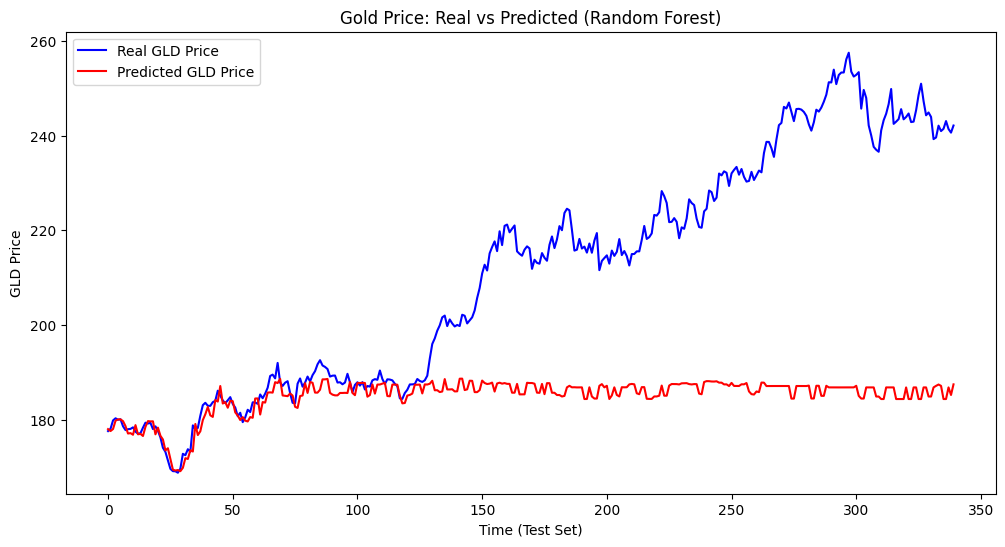

In [8]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Real GLD Price', color='blue')
plt.plot(y_test_pred, label='Predicted GLD Price', color='red')
plt.title('Gold Price: Real vs Predicted (Random Forest)')
plt.xlabel('Time (Test Set)')
plt.ylabel('GLD Price')
plt.legend()
plt.show()